In [2]:
import pandas as pd

/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("virginia_housing_raw.csv")

In [4]:
df.shape
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 66 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_url             9800 non-null   object 
 1   property_id              9800 non-null   int64  
 2   listing_id               9800 non-null   int64  
 3   permalink                9800 non-null   object 
 4   mls                      9800 non-null   object 
 5   mls_id                   9800 non-null   object 
 6   status                   9800 non-null   object 
 7   mls_status               9215 non-null   object 
 8   text                     9714 non-null   object 
 9   style                    9800 non-null   object 
 10  formatted_address        9800 non-null   object 
 11  full_street_line         9772 non-null   object 
 12  street                   9712 non-null   object 
 13  unit                     1361 non-null   object 
 14  city                    

property_url         0
property_id          0
listing_id           0
permalink            0
mls                  0
                  ... 
office_email      1573
office_phones      686
nearby_schools    9800
primary_photo       84
alt_photos          84
Length: 66, dtype: int64

### Removing Feautres

For now, we are going to remove features we know we are not going to need or features that are missing all or most of their data.

In [6]:
df = df.copy()

In [7]:
drop_cols = [

    # IDs
    "property_id",
    "listing_id",
    "mls_id",
    "agent_id",
    "agent_nrds_id",
    "broker_id",
    "builder_id",
    "office_id",

    # links / media
    "property_url",
    "permalink",
    "primary_photo",
    "alt_photos",

    # contact / names
    "mls",
    "agent_name",
    "agent_email",
    "agent_phones",
    "agent_mls_set",
    "broker_name",
    "builder_name",
    "office_name",
    "office_email",
    "office_phones",
    "office_mls_set",

    # empty columns
    "list_price_min",
    "list_price_max",
    "assessed_value",
    "tax",
    "tax_history",
    "nearby_schools",
    "neighborhoods",

    # leakage / historical sale info
    "sold_price",
    "last_sold_price",
    "last_sold_date",
    "pending_date",
    "last_status_change_date"
]

In [8]:
df = df.drop(columns=drop_cols)
print(df.columns.tolist())
print(df.shape)

['status', 'mls_status', 'text', 'style', 'formatted_address', 'full_street_line', 'street', 'unit', 'city', 'state', 'zip_code', 'beds', 'full_baths', 'half_baths', 'sqft', 'year_built', 'days_on_mls', 'list_price', 'list_date', 'last_update_date', 'estimated_value', 'new_construction', 'lot_sqft', 'price_per_sqft', 'latitude', 'longitude', 'county', 'fips_code', 'stories', 'hoa_fee', 'parking_garage']
(9800, 31)


### Data Exploration

Now we're going to do some baseline data exploration to understand the dataset we are working with.

In [10]:
df.shape
df.head()
df.describe(include="all")

,status,mls_status,text,style,formatted_address,full_street_line,street,unit,city,state,...,new_construction,lot_sqft,price_per_sqft,latitude,longitude,county,fips_code,stories,hoa_fee,parking_garage
count,9800,9215,9714,9800,9800,9772,9712,1361,9800,9800,...,9800,7.607000e+03,8508.000000,9181.000000,9181.000000,9607,7719.000000,7694.000000,6281.000000,4167.000000
unique,3,2,8941,10,9044,9003,8713,708,586,1,...,2,NaN,NaN,NaN,NaN,131,NaN,NaN,NaN,NaN
top,FOR_SALE,Active,"Introducing the St. Paul, one of Maronda's lat...",SINGLE_FAMILY,"Mount Crawford, VA, 22841",Sturgeon Rd,Rivermont Acres Rd,Unit A,Alexandria,VA,...,False,NaN,NaN,NaN,NaN,Fairfax,NaN,NaN,NaN,NaN
freq,7360,7459,18,5977,13,6,12,42,274,9800,...,7988,NaN,NaN,NaN,NaN,936,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.996790e+05,272.442525,37.881281,-77.875297,NaN,51092.123462,2.002469,112.079924,2.228942
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.515091e+07,171.497091,0.797924,1.326147,NaN,64.477160,0.804491,190.563037,15.748485
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.000000e+00,7.000000,36.543319,-83.549896,NaN,51001.000000,1.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.276000e+03,199.000000,37.237000,-78.473176,NaN,51053.000000,1.000000,0.000000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.999800e+04,242.000000,37.780537,-77.524909,NaN,51087.000000,2.000000,25.000000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.740300e+04,306.000000,38.733582,-77.126604,NaN,51139.000000,3.000000,143.000000,2.000000


In [11]:
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": round(df.isna().mean()*100,2)
})

missing.sort_values("Missing_Percent", ascending=False)

,Missing_Count,Missing_Percent
unit,8439,86.11
parking_garage,5633,57.48
half_baths,5215,53.21
hoa_fee,3519,35.91
estimated_value,2559,26.11
lot_sqft,2193,22.38
stories,2106,21.49
fips_code,2081,21.23
year_built,1794,18.31
full_baths,1333,13.60


Dropping rows that is missing list price and text since those two variables are crucial for this research.

In [12]:
df = df.dropna(subset=["list_price", "text"])

Because units is missing so much data, we are also going to drop that column.

In [14]:
df = df.drop(columns=["unit"])

It's not ideal to fill in the missing data for lat and long using the median. For the purpose of the initial model, we will be using the zip_code and county and we'll be using lat and long if we're going to build maps later.

In [15]:
model_df = df.copy()
df = df.drop(columns=["latitude", "longitude"]).copy()

print("df shape (no lat/long):", df.shape)
print("model_df shape (with lat/long):", model_df.shape)

print("\ndf columns:")
print(df.columns.tolist())

print("\nmodel_df columns:")
print(model_df.columns.tolist())

df shape (no lat/long): (9708, 28)
model_df shape (with lat/long): (9708, 30)

df columns:
['status', 'mls_status', 'text', 'style', 'formatted_address', 'full_street_line', 'street', 'city', 'state', 'zip_code', 'beds', 'full_baths', 'half_baths', 'sqft', 'year_built', 'days_on_mls', 'list_price', 'list_date', 'last_update_date', 'estimated_value', 'new_construction', 'lot_sqft', 'price_per_sqft', 'county', 'fips_code', 'stories', 'hoa_fee', 'parking_garage']

model_df columns:
['status', 'mls_status', 'text', 'style', 'formatted_address', 'full_street_line', 'street', 'city', 'state', 'zip_code', 'beds', 'full_baths', 'half_baths', 'sqft', 'year_built', 'days_on_mls', 'list_price', 'list_date', 'last_update_date', 'estimated_value', 'new_construction', 'lot_sqft', 'price_per_sqft', 'latitude', 'longitude', 'county', 'fips_code', 'stories', 'hoa_fee', 'parking_garage']


I'm going to do some feature engineering before dropping some of these unimportant features.

In [19]:
# Year built
df["home_age"] = 2026 - df["year_built"]

In [20]:
# Total Baths
df["total_baths"] = df["full_baths"] + 0.5 * df["half_baths"]

In [21]:
df["desc_words"] = df["text"].str.split().str.len()

In [22]:
df["status"] = df["status"].replace({
    "CONTINGENT": "PENDING"
})

In [23]:
df["list_date"] = pd.to_datetime(df["list_date"])
df["listing_month"] = df["list_date"].dt.month

Let's check for weak features that we could drop before beginning filling for missing data. 

In [16]:
num_check = [
    "beds",
    "full_baths",
    "half_baths",
    "sqft",
    "year_built",
    "lot_sqft",
    "estimated_value",
    "stories",
    "hoa_fee",
    "parking_garage",
    "days_on_mls",
    "list_price"
]

df[num_check].corr()["list_price"].sort_values(ascending=False)

list_price         1.000000
estimated_value    0.885859
sqft               0.512993
full_baths         0.475686
beds               0.361092
half_baths         0.322857
stories            0.273481
year_built         0.043821
lot_sqft           0.014669
days_on_mls        0.013226
parking_garage     0.006973
hoa_fee           -0.007724
Name: list_price, dtype: float64

In [17]:
df.groupby("style")["list_price"].mean().sort_values(ascending=False)

df.groupby("county")["list_price"].mean().sort_values(ascending=False)

df.groupby("status")["list_price"].mean()

status
CONTINGENT    662013.660322
FOR_SALE      593068.096889
PENDING       558117.984954
Name: list_price, dtype: float64

In [18]:
missing = pd.DataFrame({
    "missing_pct": df.isna().mean()*100
})

missing["corr_price"] = df.corr(numeric_only=True)["list_price"]

missing.sort_values("missing_pct", ascending=False)

,missing_pct,corr_price
parking_garage,57.447466,0.006973
half_baths,53.131438,0.322857
hoa_fee,35.990935,-0.007724
estimated_value,26.060981,0.885859
lot_sqft,22.404203,0.014669
stories,21.415328,0.273481
fips_code,21.291718,-0.062937
year_built,18.222085,0.043821
full_baths,13.483725,0.475686
price_per_sqft,13.009889,0.638014


In [24]:
drop_cols = [
    "parking_garage",
    "hoa_fee",
    "lot_sqft",
    "fips_code",
    "street",
    "full_street_line",
    "estimated_value",
    "price_per_sqft"
]

df = df.drop(columns=drop_cols)

Let's handle the missing data for the rest of the features

In [25]:
# For the numeric features

df["beds"] = df["beds"].fillna(df["beds"].median())
df["full_baths"] = df["full_baths"].fillna(df["full_baths"].median())
df["half_baths"] = df["half_baths"].fillna(0)
df["sqft"] = df["sqft"].fillna(df["sqft"].median())
df["year_built"] = df["year_built"].fillna(df["year_built"].median())
df["stories"] = df["stories"].fillna(df["stories"].median())

In [26]:
# Categorical

df["mls_status"] = df["mls_status"].fillna("Unknown")
df["county"] = df["county"].fillna("Unknown")

In [27]:
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": round(df.isna().mean()*100,2)
})

missing.sort_values("Missing_Percent", ascending=False)

,Missing_Count,Missing_Percent
total_baths,5165,53.20
home_age,1769,18.22
days_on_mls,12,0.12
status,0,0.00
mls_status,0,0.00
desc_words,0,0.00
stories,0,0.00
county,0,0.00
new_construction,0,0.00
last_update_date,0,0.00


In [28]:
df["total_baths"] = df["full_baths"] + 0.5 * df["half_baths"]

In [30]:
df["home_age"] = 2026 - df["year_built"]

In [32]:
df["days_on_mls"] = df["days_on_mls"].fillna(df["days_on_mls"].median())

### Checking for Skewness

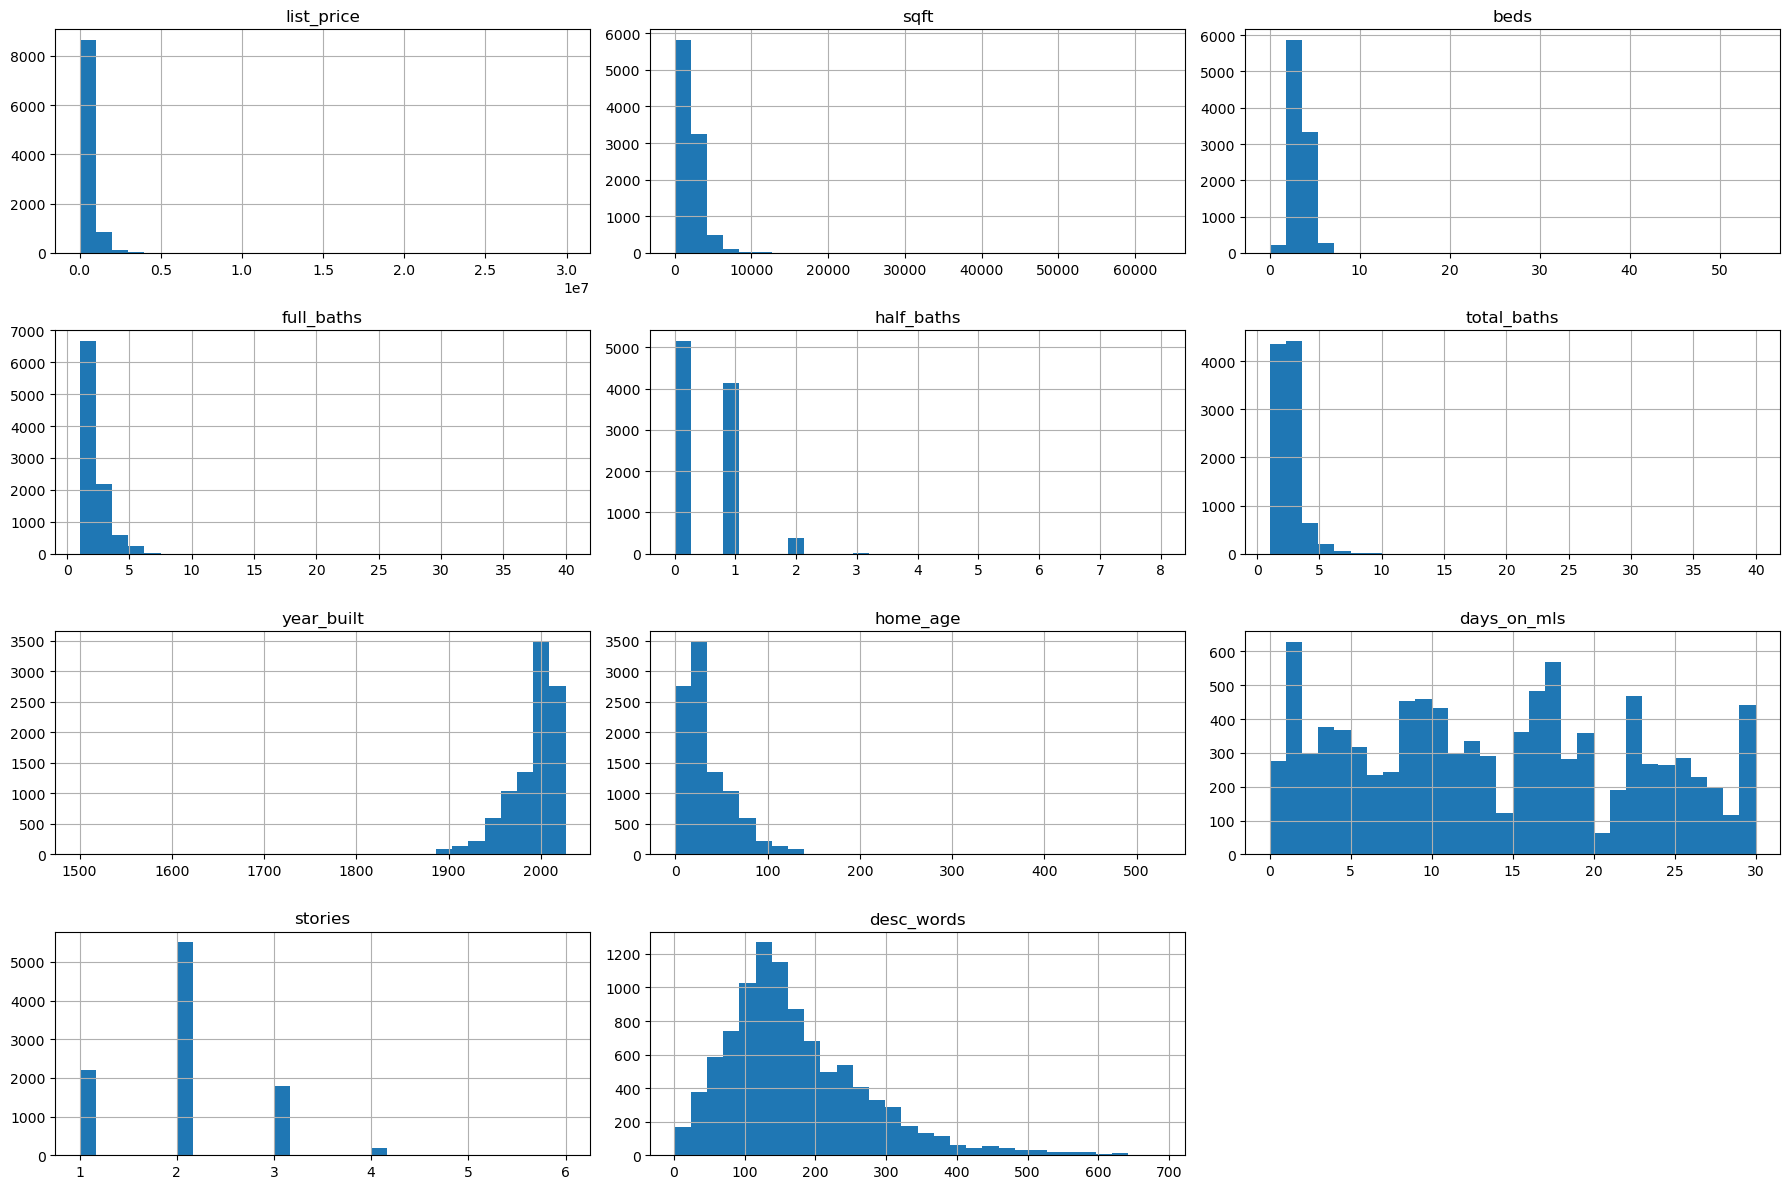

In [34]:
# =====================================================
# CHECK DISTRIBUTION OF NUMERIC FEATURES
# =====================================================

import matplotlib.pyplot as plt

num_cols = [
    "list_price",
    "sqft",
    "beds",
    "full_baths",
    "half_baths",
    "total_baths",
    "year_built",
    "home_age",
    "days_on_mls",
    "stories",
    "desc_words"
]

# histograms
df[num_cols].hist(figsize=(18,12), bins=30)
plt.tight_layout()
plt.show()

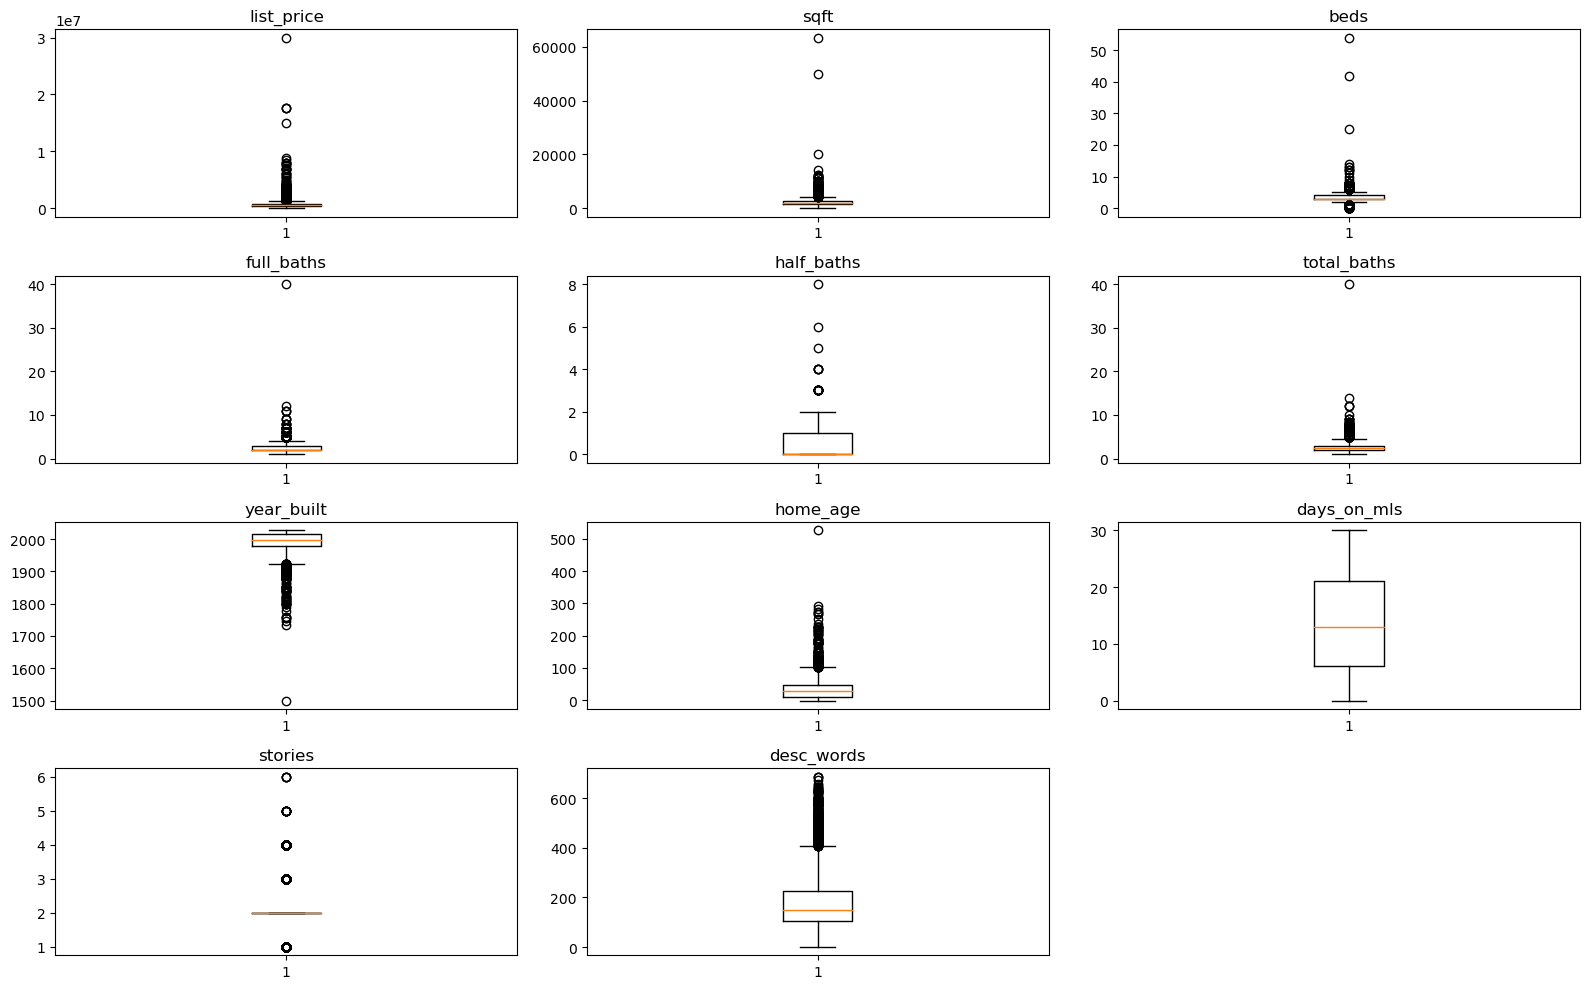

In [35]:
# =====================================================
# BOXPLOTS (good for skewness + outliers)
# =====================================================

plt.figure(figsize=(16,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,3,i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

In [36]:
# =====================================================
# SKEWNESS TABLE
# =====================================================

df[num_cols].skew().sort_values(ascending=False)

list_price     14.554751
sqft           12.709206
beds           11.151515
full_baths      7.095360
total_baths     5.524918
home_age        2.154319
desc_words      1.280719
half_baths      1.056054
stories         0.464246
days_on_mls     0.158342
year_built     -2.154319
dtype: float64

In [37]:
# =====================================================
# SUMMARY STATISTICS
# =====================================================

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
list_price,9708.0,591697.683457,715592.989512,250.0,307950.0,450000.0,695000.0,29950000.0
sqft,9708.0,2293.327050,1456.851511,0.0,1558.0,2011.0,2642.0,63344.0
beds,9708.0,3.400906,1.242083,0.0,3.0,3.0,4.0,54.0
full_baths,9708.0,2.336527,0.988216,1.0,2.0,2.0,3.0,40.0
half_baths,9708.0,0.515245,0.597955,0.0,0.0,0.0,1.0,8.0
total_baths,9708.0,2.594149,1.089672,1.0,2.0,2.5,3.0,40.0
year_built,9708.0,1992.447981,30.373372,1500.0,1979.0,1998.0,2016.0,2027.0
home_age,9708.0,33.552019,30.373372,-1.0,10.0,28.0,47.0,526.0
days_on_mls,9708.0,13.459003,8.561588,0.0,6.0,13.0,21.0,30.0
stories,9708.0,2.001030,0.711210,1.0,2.0,2.0,2.0,6.0


In [38]:
# =====================================================
# CATEGORICAL FEATURE DISTRIBUTIONS
# =====================================================

cat_cols = ["status", "style", "county", "new_construction"]

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts().head(15))


 status
status
FOR_SALE    7297
PENDING     2411
Name: count, dtype: int64

 style
style
SINGLE_FAMILY                  5927
TOWNHOMES                      1419
LAND                           1204
CONDOS                          896
MOBILE                          115
MULTI_FAMILY                     93
FARM                             30
DUPLEX_TRIPLEX                   13
APARTMENT                         7
CONDO_TOWNHOME_ROWHOME_COOP       4
Name: count, dtype: int64

 county
county
Fairfax                923
Chesterfield           455
Loudoun                436
Prince William         410
Henrico                268
Virginia Beach City    218
Frederick              217
Albemarle              217
Stafford               196
Unknown                193
Richmond City          189
Chesapeake City        181
Bedford                175
Arlington              165
James City             148
Name: count, dtype: int64

 new_construction
new_construction
False    7904
True     1804
Name: count, 

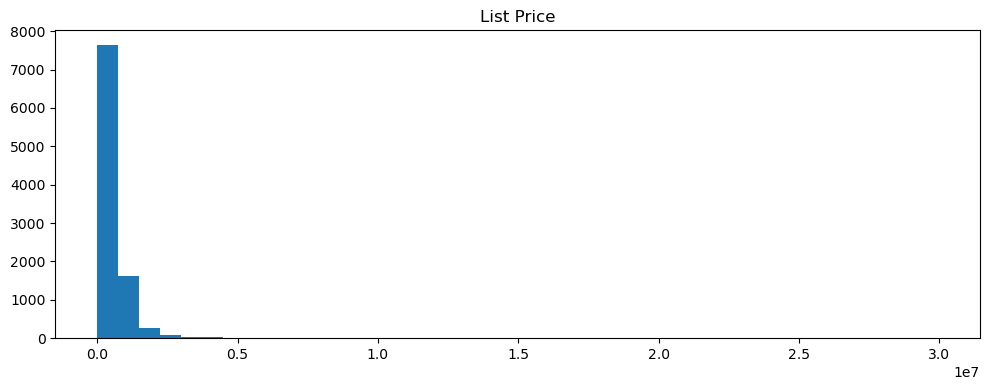

In [40]:
# =====================================================
# PRICE DISTRIBUTION ONLY
# =====================================================

plt.figure(figsize=(10,4))

plt.hist(df["list_price"], bins=40)
plt.title("List Price")

plt.tight_layout()
plt.show()

We can see that list price and sqft is very skewed.

In [42]:
import numpy as np

In [43]:
df["log_price"] = np.log(df["list_price"])
df["log_sqft"] = np.log(df["sqft"])

/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [53]:
df = df[df["sqft"] > 0]
df["log_sqft"] = np.log(df["sqft"])

The beds and total baths have outliers so we'll be capping the outliers.

In [44]:
df = df[df["beds"] <= 10]
df = df[df["total_baths"] <= 10]

Home age has a negative age and an extreme outlier that will may our model less accurate. 

In [46]:
df.loc[df["home_age"] < 0, "home_age"] = 0
df.loc[df["year_built"] < 1600, "year_built"] = np.nan

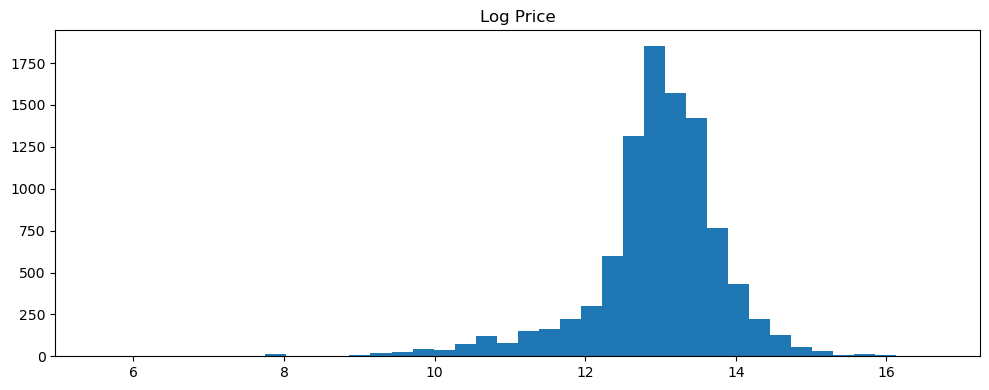

In [47]:
plt.figure(figsize=(10,4))

plt.hist(df["log_price"], bins=40)
plt.title("Log Price")

plt.tight_layout()
plt.show()

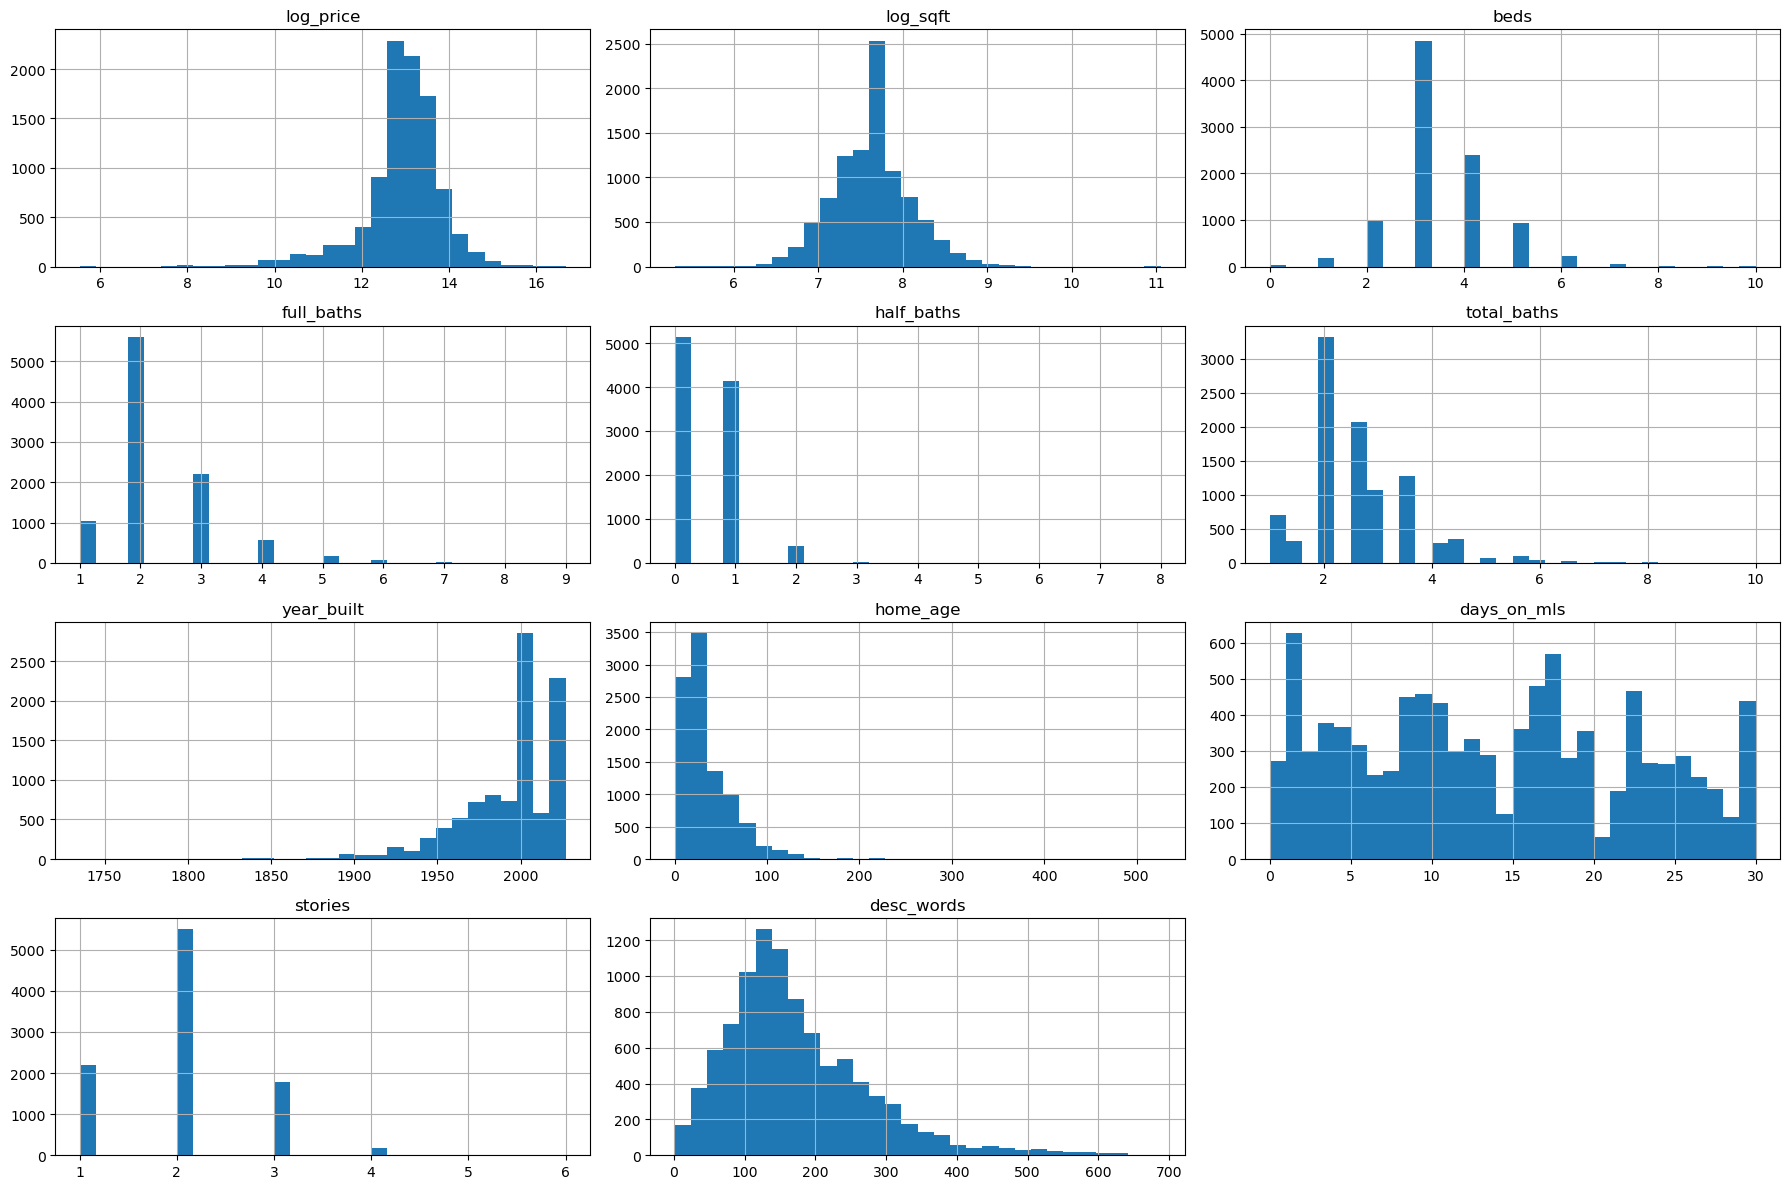

In [54]:
num_cols = [
    "log_price",
    "log_sqft",
    "beds",
    "full_baths",
    "half_baths",
    "total_baths",
    "year_built",
    "home_age",
    "days_on_mls",
    "stories",
    "desc_words"
]

# histograms
df[num_cols].hist(figsize=(18,12), bins=30)
plt.tight_layout()
plt.show()

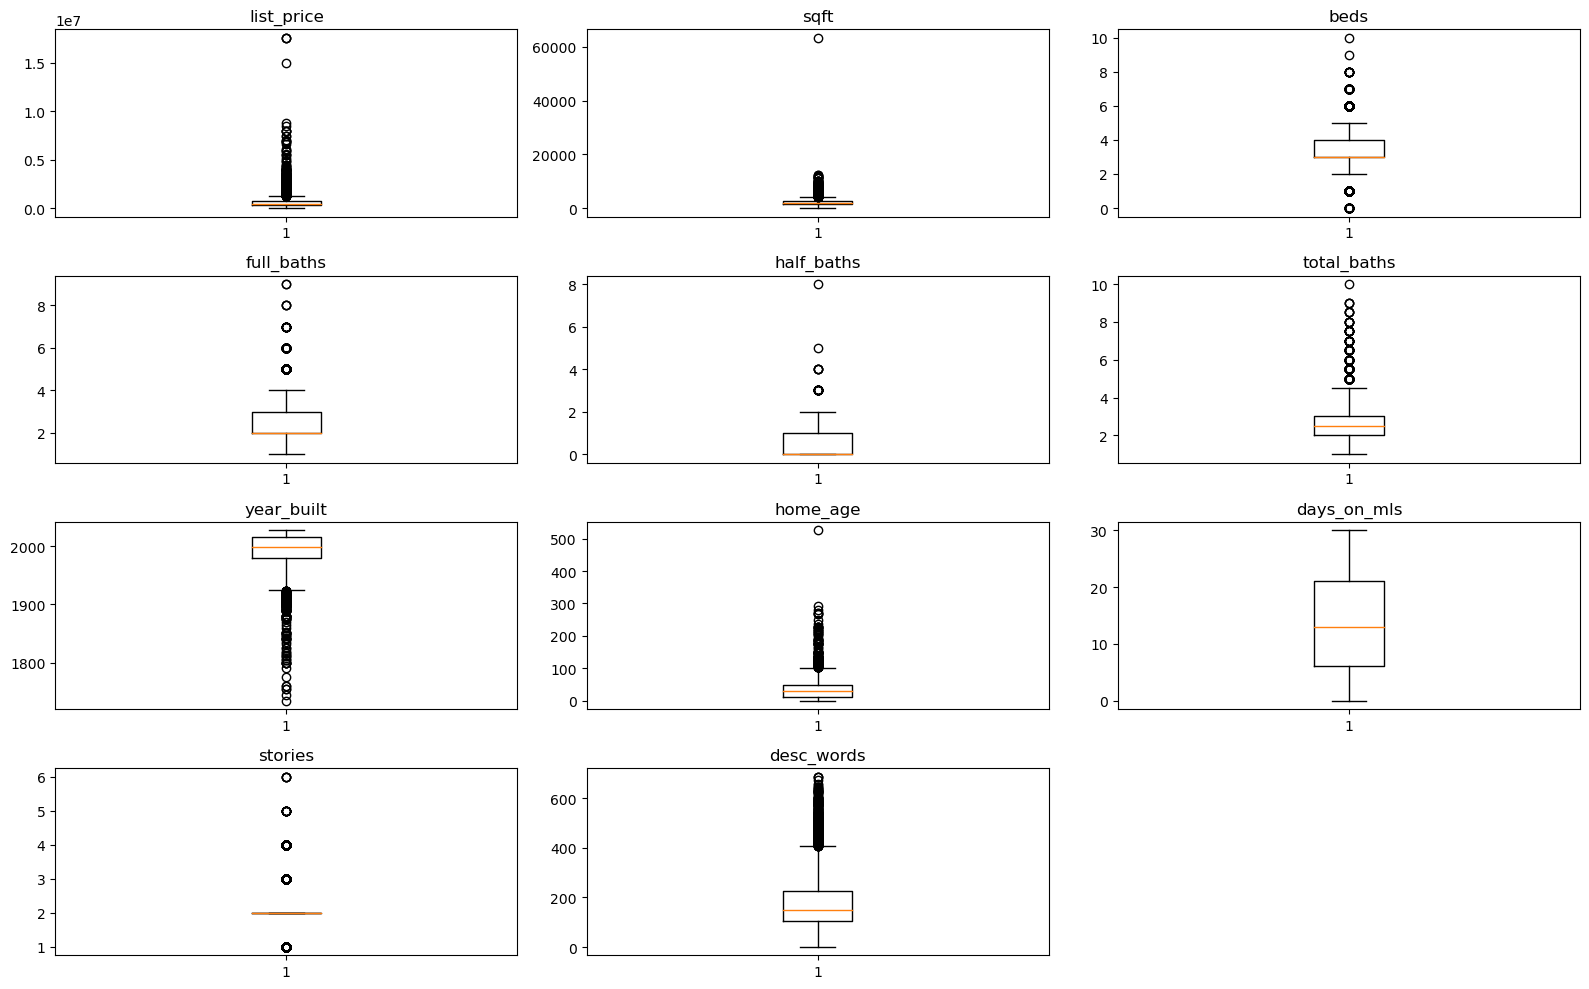

In [51]:
plt.figure(figsize=(16,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,3,i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

### Checking for Imbalancing

In [56]:
df["style"].value_counts()

style
SINGLE_FAMILY                  5910
TOWNHOMES                      1416
LAND                           1204
CONDOS                          896
MOBILE                          113
MULTI_FAMILY                     86
FARM                             30
DUPLEX_TRIPLEX                   13
APARTMENT                         7
CONDO_TOWNHOME_ROWHOME_COOP       4
Name: count, dtype: int64

In [57]:
df["county"].value_counts()

county
Fairfax           922
Chesterfield      455
Loudoun           435
Prince William    410
Henrico           268
                 ... 
Franklin City       3
Galax City          3
Radford             3
Norton City         1
Jefferson           1
Name: count, Length: 132, dtype: int64

In [58]:
df["status"].value_counts()

status
FOR_SALE    7269
PENDING     2410
Name: count, dtype: int64

In [59]:
df["new_construction"].value_counts()

new_construction
False    7875
True     1804
Name: count, dtype: int64

In [60]:
df["stories"].value_counts()

stories
2.0    5492
1.0    2198
3.0    1788
4.0     186
5.0      11
6.0       4
Name: count, dtype: int64

In [61]:
df["beds"].value_counts()

beds
3.0     4849
4.0     2384
2.0     1007
5.0      944
6.0      217
1.0      184
7.0       51
0.0       32
8.0        9
9.0        1
10.0       1
Name: count, dtype: int64

In [62]:
df["full_baths"].value_counts()

full_baths
2.0    5611
3.0    2194
1.0    1045
4.0     578
5.0     166
6.0      65
7.0      15
8.0       3
9.0       2
Name: count, dtype: int64

In [63]:
df["half_baths"].value_counts()

half_baths
0.0    5141
1.0    4132
2.0     378
3.0      22
4.0       4
5.0       1
8.0       1
Name: count, dtype: int64

In [64]:
df["total_baths"].value_counts()

total_baths
2.0     3324
2.5     2076
3.5     1273
3.0     1064
1.0      709
4.5      347
1.5      319
4.0      289
5.5       94
5.0       76
6.0       35
6.5       31
7.0       17
7.5       11
8.0        6
8.5        4
9.0        3
10.0       1
Name: count, dtype: int64

In [65]:
style_counts = df["style"].value_counts()
rare_styles = style_counts[style_counts < 50].index
df["style"] = df["style"].replace(rare_styles, "OTHER")

county_counts = df["county"].value_counts()
rare_counties = county_counts[county_counts < 25].index
df["county"] = df["county"].replace(rare_counties, "OTHER")

I don't need half_baths and full_baths since I have total_baths and keeping the other two features will cause multicolinearity.

In [66]:
df["total_baths"] = df["total_baths"].clip(upper=8)
df["beds"] = df["beds"].clip(upper=8)
df["stories"] = df["stories"].replace({5:4, 6:4})

### Checking for Multicolinearity

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[[
    "log_sqft",
    "beds",
    "total_baths",
    "home_age",
    "days_on_mls",
    "desc_words"
]].dropna()

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

      Variable        VIF
0     log_sqft  25.031348
1         beds  26.144015
2  total_baths  18.356549
3     home_age   2.376302
4  days_on_mls   3.469051
5   desc_words   4.532812


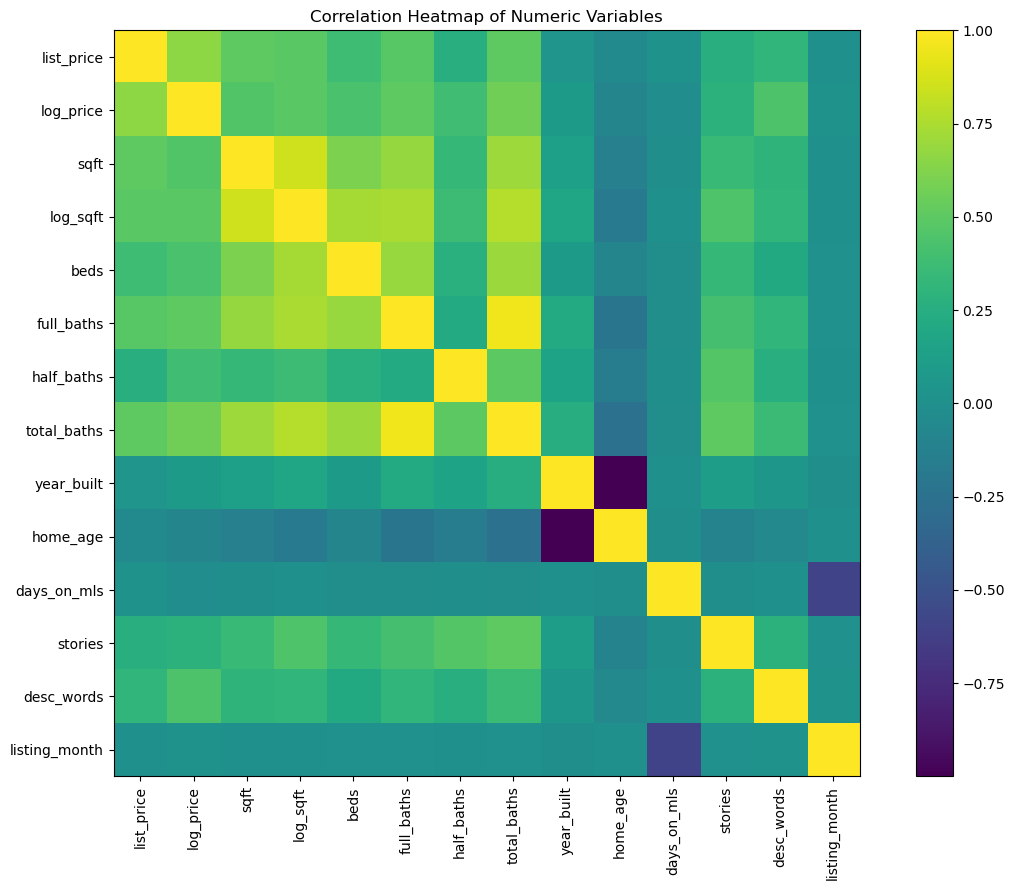

In [69]:
corr_cols = [
    "list_price",
    "log_price",
    "sqft",
    "log_sqft",
    "beds",
    "full_baths",
    "half_baths",
    "total_baths",
    "year_built",
    "home_age",
    "days_on_mls",
    "stories",
    "desc_words",
    "listing_month"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [70]:
corr_matrix.round(2)

,list_price,log_price,sqft,log_sqft,beds,full_baths,half_baths,total_baths,year_built,home_age,days_on_mls,stories,desc_words,listing_month
list_price,1.00,0.66,0.51,0.49,0.38,0.48,0.26,0.50,0.04,-0.04,0.02,0.26,0.31,0.00
log_price,0.66,1.00,0.46,0.49,0.43,0.50,0.39,0.56,0.09,-0.09,-0.02,0.28,0.44,0.02
sqft,0.51,0.46,1.00,0.86,0.60,0.69,0.33,0.71,0.13,-0.13,-0.00,0.35,0.30,0.00
log_sqft,0.49,0.49,0.86,1.00,0.73,0.75,0.37,0.78,0.18,-0.18,0.00,0.45,0.31,0.00
beds,0.38,0.43,0.60,0.73,1.00,0.69,0.27,0.70,0.09,-0.09,-0.01,0.33,0.22,0.01
full_baths,0.48,0.50,0.69,0.75,0.69,1.00,0.22,0.96,0.22,-0.22,-0.01,0.41,0.32,0.01
half_baths,0.26,0.39,0.33,0.37,0.27,0.22,1.00,0.50,0.16,-0.16,-0.01,0.47,0.26,0.00
total_baths,0.50,0.56,0.71,0.78,0.70,0.96,0.50,1.00,0.25,-0.24,-0.01,0.50,0.36,0.01
year_built,0.04,0.09,0.13,0.18,0.09,0.22,0.16,0.25,1.00,-1.00,0.00,0.11,0.06,-0.00
home_age,-0.04,-0.09,-0.13,-0.18,-0.09,-0.22,-0.16,-0.24,-1.00,1.00,-0.01,-0.11,-0.06,0.00


In [71]:
df = df.drop(columns=[
    "year_built",
    "full_baths",
    "half_baths",
    "sqft"
])

<class 'pandas.core.frame.DataFrame'>
Index: 9679 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   status             9679 non-null   object        
 1   mls_status         9679 non-null   object        
 2   text               9679 non-null   object        
 3   style              9679 non-null   object        
 4   formatted_address  9679 non-null   object        
 5   city               9679 non-null   object        
 6   state              9679 non-null   object        
 7   zip_code           9679 non-null   int64         
 8   beds               9679 non-null   float64       
 9   days_on_mls        9679 non-null   float64       
 10  list_price         9679 non-null   float64       
 11  list_date          9679 non-null   datetime64[ns]
 12  last_update_date   9679 non-null   object        
 13  new_construction   9679 non-null   bool          
 14  county       

In [73]:
df = df.drop(columns=[
    "beds"
])

In [75]:
X = df[[
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "desc_words"
]].dropna()

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

      Variable        VIF
0     log_sqft  18.179588
1  total_baths  11.922637
2     home_age   2.355275
3  days_on_mls   3.466841
4   desc_words   4.508922


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9679 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   status             9679 non-null   object        
 1   mls_status         9679 non-null   object        
 2   text               9679 non-null   object        
 3   style              9679 non-null   object        
 4   formatted_address  9679 non-null   object        
 5   city               9679 non-null   object        
 6   state              9679 non-null   object        
 7   zip_code           9679 non-null   int64         
 8   days_on_mls        9679 non-null   float64       
 9   list_price         9679 non-null   float64       
 10  list_date          9679 non-null   datetime64[ns]
 11  last_update_date   9679 non-null   object        
 12  new_construction   9679 non-null   bool          
 13  county             9679 non-null   object        
 14  stories      

In [77]:
df = df.drop(columns=[
    "mls_status",
    "formatted_address",
    "city",
    "state",
    "last_update_date"
])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9679 entries, 0 to 9799
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   status            9679 non-null   object        
 1   text              9679 non-null   object        
 2   style             9679 non-null   object        
 3   zip_code          9679 non-null   int64         
 4   days_on_mls       9679 non-null   float64       
 5   list_price        9679 non-null   float64       
 6   list_date         9679 non-null   datetime64[ns]
 7   new_construction  9679 non-null   bool          
 8   county            9679 non-null   object        
 9   stories           9679 non-null   float64       
 10  home_age          9679 non-null   float64       
 11  total_baths       9679 non-null   float64       
 12  desc_words        9679 non-null   int64         
 13  listing_month     9679 non-null   int32         
 14  log_price         9679 non-nu

### Checking Duplicates

In [78]:
df.duplicated().sum()

267

In [79]:
df[df.duplicated()]

,status,text,style,zip_code,days_on_mls,list_price,list_date,new_construction,county,stories,home_age,total_baths,desc_words,listing_month,log_price,log_sqft
200,FOR_SALE,"5816 Abilene Rd | Farmville, VA | 3 Bedrooms |...",SINGLE_FAMILY,23901,4.0,285000.0,2026-04-21 17:28:55,False,Prince Edward,1.0,24.0,2.0,258,4,12.560244,7.129298
201,FOR_SALE,"A little more space, a little more view, and a...",SINGLE_FAMILY,24090,10.0,424950.0,2026-04-16 11:36:39,False,Botetourt,1.0,22.0,3.0,123,4,12.959727,7.886457
204,FOR_SALE,Discover your next home at 984 Colbourne Ave i...,SINGLE_FAMILY,24179,22.0,269900.0,2026-04-03 17:05:54,False,Roanoke,2.0,63.0,2.0,112,4,12.505807,7.556951
205,FOR_SALE,Set along one of Charlottesville's most charac...,SINGLE_FAMILY,22903,2.0,695000.0,2026-04-24 12:26:35,False,Charlottesville City,2.0,101.0,2.5,188,4,13.451667,7.763871
206,FOR_SALE,Unique Round Home on a premium point peninsula...,SINGLE_FAMILY,22473,16.0,485000.0,2026-04-09 13:32:44,False,Northumberland,1.0,44.0,2.0,174,4,13.091904,7.459915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9612,FOR_SALE,"Introducing the St. Paul, one of Maronda's lat...",MULTI_FAMILY,22841,8.0,299990.0,2026-04-18 02:01:08,True,Rockingham,2.0,28.0,2.5,245,4,12.611504,7.314553
9631,FOR_SALE,"Introducing the St. Paul, one of Maronda's lat...",MULTI_FAMILY,22841,8.0,299990.0,2026-04-18 02:01:08,True,Rockingham,2.0,28.0,2.5,245,4,12.611504,7.314553
9650,FOR_SALE,Experience effortless living in our Willow Run...,TOWNHOMES,22602,1.0,459990.0,2026-04-25 00:06:47,True,Frederick,1.0,28.0,2.0,183,4,13.038960,7.681560
9679,FOR_SALE,Experience effortless living in our Willow Run...,TOWNHOMES,22602,1.0,519990.0,2026-04-25 00:06:47,True,Frederick,1.0,28.0,3.0,183,4,13.161565,7.681560


In [80]:
original = pd.read_csv("virginia_housing_raw.csv")

df["formatted_address"] = original.loc[df.index, "formatted_address"]

In [81]:
df[df.duplicated(subset=["formatted_address", "list_price", "list_date"], keep=False)]

,status,text,style,zip_code,days_on_mls,list_price,list_date,new_construction,county,stories,home_age,total_baths,desc_words,listing_month,log_price,log_sqft,formatted_address
194,FOR_SALE,"5816 Abilene Rd | Farmville, VA | 3 Bedrooms |...",SINGLE_FAMILY,23901,4.0,285000.0,2026-04-21 17:28:55,False,Prince Edward,1.0,24.0,2.0,258,4,12.560244,7.129298,"5816 Abilene Rd, Farmville, VA, 23901"
195,FOR_SALE,"A little more space, a little more view, and a...",SINGLE_FAMILY,24090,10.0,424950.0,2026-04-16 11:36:39,False,Botetourt,1.0,22.0,3.0,123,4,12.959727,7.886457,"686 Pinehaven Rd, Fincastle, VA, 24090"
196,FOR_SALE,Discover your next home at 984 Colbourne Ave i...,SINGLE_FAMILY,24179,22.0,269900.0,2026-04-03 17:05:54,False,Roanoke,2.0,63.0,2.0,112,4,12.505807,7.556951,"984 Colbourne Ave, Vinton, VA, 24179"
197,FOR_SALE,Set along one of Charlottesville's most charac...,SINGLE_FAMILY,22903,2.0,695000.0,2026-04-24 12:26:35,False,Charlottesville City,2.0,101.0,2.5,188,4,13.451667,7.763871,"2642 Jefferson Park Cir, Charlottesville, VA, ..."
198,FOR_SALE,Unique Round Home on a premium point peninsula...,SINGLE_FAMILY,22473,16.0,485000.0,2026-04-09 13:32:44,False,Northumberland,1.0,44.0,2.0,174,4,13.091904,7.459915,"89 Holiday Dr, Heathsville, VA, 22473"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9589,FOR_SALE,"Introducing the St. Paul, one of Maronda's lat...",MULTI_FAMILY,22841,8.0,299990.0,2026-04-18 02:01:08,True,Rockingham,2.0,28.0,2.5,245,4,12.611504,7.314553,"Mount Crawford, VA, 22841"
9598,FOR_SALE,"Introducing the St. Paul, one of Maronda's lat...",MULTI_FAMILY,22841,8.0,302990.0,2026-04-18 02:01:08,True,Rockingham,2.0,28.0,2.5,245,4,12.621455,7.314553,"Mount Crawford, VA, 22841"
9600,FOR_SALE,"Introducing the St. Paul, one of Maronda's lat...",MULTI_FAMILY,22841,8.0,302990.0,2026-04-18 02:01:08,True,Rockingham,2.0,28.0,2.5,245,4,12.621455,7.314553,"Mount Crawford, VA, 22841"
9612,FOR_SALE,"Introducing the St. Paul, one of Maronda's lat...",MULTI_FAMILY,22841,8.0,299990.0,2026-04-18 02:01:08,True,Rockingham,2.0,28.0,2.5,245,4,12.611504,7.314553,"Mount Crawford, VA, 22841"


In [82]:
df.duplicated(subset=["formatted_address", "list_price", "list_date"]).sum()

256

In [83]:
df = df.drop_duplicates(
    subset=["formatted_address", "list_price", "list_date"],
    keep="first"
)

print(df.duplicated(subset=["formatted_address", "list_price", "list_date"]).sum())
print(df.shape)

0
(9423, 17)


In [84]:
df = df.drop(columns=["formatted_address"])

### Final Check Before Modeling

In [85]:
df.isna().sum().sort_values(ascending=False)

status              0
text                0
style               0
zip_code            0
days_on_mls         0
list_price          0
list_date           0
new_construction    0
county              0
stories             0
home_age            0
total_baths         0
desc_words          0
listing_month       0
log_price           0
log_sqft            0
dtype: int64

In [86]:
df.duplicated().sum()

17

In [87]:
df[df.duplicated(subset=["list_price", "list_date"], keep=False)]

,status,text,style,zip_code,days_on_mls,list_price,list_date,new_construction,county,stories,home_age,total_baths,desc_words,listing_month,log_price,log_sqft
79,FOR_SALE,Don't miss this potential income-producing or ...,SINGLE_FAMILY,23336,7.0,230000.0,2026-04-19 10:26:18,False,Accomack,1.0,86.0,1.0,69,4,12.345835,6.573680
103,FOR_SALE,This one-of-a-kind (and 100% one-level living)...,SINGLE_FAMILY,22630,1.0,499999.0,2026-04-24 21:37:35,False,Warren,1.0,45.0,2.0,253,4,13.122361,7.575585
310,FOR_SALE,"CALLING ALL INVESTORS! This 4BR, 3 full bath s...",SINGLE_FAMILY,22193,1.0,400000.0,2026-04-24 21:37:35,False,Prince William,2.0,50.0,3.0,145,4,12.899220,7.696213
373,FOR_SALE,Breathtaking and unobstructed views of the Mas...,SINGLE_FAMILY,22644,1.0,895000.0,2026-04-24 21:37:35,False,Shenandoah,2.0,4.0,3.5,432,4,13.704579,8.058327
441,FOR_SALE,Welcome to Goodwood-your escape from the every...,SINGLE_FAMILY,22711,1.0,550000.0,2026-04-24 21:37:35,False,OTHER,1.0,1.0,1.0,242,4,13.217674,6.982863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9650,FOR_SALE,Experience effortless living in our Willow Run...,TOWNHOMES,22602,1.0,459990.0,2026-04-25 00:06:47,True,Frederick,1.0,28.0,2.0,183,4,13.038960,7.681560
9679,FOR_SALE,Experience effortless living in our Willow Run...,TOWNHOMES,22602,1.0,519990.0,2026-04-25 00:06:47,True,Frederick,1.0,28.0,3.0,183,4,13.161565,7.681560
9706,FOR_SALE,"Welcome to the Penwell, a beautifully designed...",SINGLE_FAMILY,22980,21.0,428790.0,2026-04-05 00:06:31,True,Unknown,2.0,28.0,2.5,162,4,12.968723,7.672292
9755,FOR_SALE,"Welcome home to the Brushwood, a beautifully d...",TOWNHOMES,23111,25.0,470740.0,2026-04-01 00:07:15,True,Hanover,2.0,28.0,2.5,220,4,13.062061,7.580700


In [90]:
df[df.duplicated(keep=False)].sort_values("list_price")

,status,text,style,zip_code,days_on_mls,list_price,list_date,new_construction,county,stories,home_age,total_baths,desc_words,listing_month,log_price,log_sqft
6547,FOR_SALE,Three adjoining wooded residential lots (Lots ...,LAND,23322,29.0,12000.0,2026-03-28 10:21:12,False,Unknown,2.0,28.0,2.0,99,3,9.392662,7.606387
6548,FOR_SALE,Three adjoining wooded residential lots (Lots ...,LAND,23322,29.0,12000.0,2026-03-28 10:21:12,False,Unknown,2.0,28.0,2.0,99,3,9.392662,7.606387
6549,FOR_SALE,Three adjoining wooded residential lots (Lots ...,LAND,23322,29.0,12000.0,2026-03-28 10:21:12,False,Unknown,2.0,28.0,2.0,99,3,9.392662,7.606387
7881,FOR_SALE,Build your dream home! Convenient location wit...,LAND,24441,0.0,80000.0,2026-04-25 16:47:53,False,Augusta,2.0,28.0,2.0,20,4,11.289782,7.606387
6809,FOR_SALE,Build your dream home! Convenient location wit...,LAND,24441,0.0,80000.0,2026-04-25 16:47:53,False,Augusta,2.0,28.0,2.0,20,4,11.289782,7.606387
8513,FOR_SALE,NEW CONSTRUCTION!! Old Belt Townhomes located ...,TOWNHOMES,24541,5.0,269000.0,2026-04-20 19:36:43,True,Unknown,2.0,0.0,2.5,120,4,12.502467,7.326466
7515,FOR_SALE,NEW CONSTRUCTION!! Old Belt Townhomes located ...,TOWNHOMES,24541,5.0,269000.0,2026-04-20 19:36:43,True,Unknown,2.0,0.0,2.5,120,4,12.502467,7.326466
7572,FOR_SALE,NEW CONSTRUCTION!! Old Belt Townhomes located ...,TOWNHOMES,24541,5.0,269000.0,2026-04-20 19:36:43,True,Unknown,2.0,0.0,2.5,120,4,12.502467,7.326466
4574,FOR_SALE,Discover this exciting new construction opport...,TOWNHOMES,22801,11.0,305000.0,2026-04-14 14:28:26,True,Unknown,3.0,0.0,2.5,186,4,12.628067,7.167809
9795,FOR_SALE,Discover this exciting new construction opport...,TOWNHOMES,22801,11.0,305000.0,2026-04-14 14:28:26,True,Unknown,3.0,0.0,2.5,186,4,12.628067,7.167809


In [91]:
df = df.drop_duplicates(keep="first")

print(df.duplicated().sum())
print(df.shape)

0
(9406, 16)


In [96]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
zip_code,9406.0,22907.388794,20105.0,22408.0,23112.0,23704.0,24651.0,1186.552477
days_on_mls,9406.0,13.452796,0.0,6.0,13.0,21.0,30.0,8.558983
list_price,9406.0,586906.450882,250.0,308250.0,450000.0,696338.75,17599999.0,629718.953466
list_date,9406,2026-04-12 13:10:06.504890624,2026-03-27 00:02:39,2026-04-05 10:25:07,2026-04-13 06:30:47,2026-04-20 00:27:03,2026-04-26 16:28:26,NaN
stories,9406.0,2.000532,1.0,2.0,2.0,2.0,4.0,0.704131
home_age,9406.0,33.644482,0.0,11.0,28.0,47.0,526.0,30.369588
total_baths,9406.0,2.585531,1.0,2.0,2.5,3.0,8.0,0.994987
desc_words,9406.0,173.958112,1.0,106.0,151.0,226.0,688.0,102.1141
listing_month,9406.0,3.882415,3.0,4.0,4.0,4.0,4.0,0.322133
log_price,9406.0,12.954322,5.521461,12.638665,13.017003,13.453591,16.683409,0.890009


In [97]:
df.to_csv("virginia_housing_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print(df.shape)

Cleaned dataset saved successfully.
(9406, 16)
